# Practical Statistics for Data Scientists (Python + R)
# Chapter 6. Statistical Machine Learning
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck


## Loading the rpy2 extension in a notebook with the Python kernel


In [1]:
import sys
import io

stderr_original = sys.stderr
sys.stderr = io.StringIO()

%load_ext rpy2.ipython

sys.stderr = stderr_original


In [2]:
%%R
suppressWarnings(
  invisible(
    try(Sys.setlocale("LC_ALL", "English"), silent = TRUE)
  )
)

## Import packages


### Import required Python packages


In [3]:
import math
import os
import random
from pathlib import Path
from collections import defaultdict
from itertools import product


import pandas as pd
import numpy as np

from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from dmba import plotDecisionTree, textDecisionTree

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

%matplotlib inline

In [4]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

### Import required R packages


In [5]:
%%R
Sys.setlocale("LC_ALL", "en_US.UTF-8")
# Install missing packages if needed
packages <- c("dplyr", "ggplot2", "FNN", "rpart", "randomForest", "xgboost")
installed <- rownames(installed.packages())
to_install <- packages[!packages %in% installed]
if (length(to_install) > 0) {
  install.packages(to_install, repos = 'https://cloud.r-project.org/')
}

# Load them all
library(dplyr)
library(ggplot2)
library(FNN)
library(rpart)
library(randomForest)
library(xgboost)


Dołączanie pakietu: 'dplyr'

Następujące obiekty zostały zakryte z 'package:stats':

    filter, lag

Następujące obiekty zostały zakryte z 'package:base':

    intersect, setdiff, setequal, union

randomForest 4.7-1.2
Type rfNews() to see new features/changes/bug fixes.

Dołączanie pakietu: 'randomForest'

Następujący obiekt został zakryty z 'package:ggplot2':

    margin

Następujący obiekt został zakryty z 'package:dplyr':

    combine

In addition: Warning messages:
1: In Sys.setlocale("LC_ALL", "en_US.UTF-8") :
  using locale code page other than 1250 may cause problems
2: pakiet 'randomForest' został zbudowany w wersji R 4.5.3 
3: pakiet 'xgboost' został zbudowany w wersji R 4.5.3 


## Defining data paths


### Python
Python defines file paths for chapter datasets and configures XGBoost compatibility settings.


In [6]:
LOAN200_CSV = DATA / 'loan200.csv'
LOAN3000_CSV = DATA / 'loan3000.csv'
LOAN_DATA_CSV = DATA / 'loan_data.csv.gz'

In [7]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

### R
R loads the same chapter datasets and sets the same environment fallback for XGBoost training.


In [8]:
%%R
PSDS_PATH <- file.path(dirname(dirname(getwd())))

loan200 <- read.csv(file.path(PSDS_PATH, 'data', 'loan200.csv'), stringsAsFactors=TRUE)
loan200$outcome <- ordered(loan200$outcome, levels=c('paid off', 'default'))

loan3000 <- read.csv(file.path(PSDS_PATH, 'data', 'loan3000.csv'), stringsAsFactors=TRUE)
loan3000$outcome <- ordered(loan3000$outcome, levels=c('paid off', 'default'))

loan_data <- read.csv(file.path(PSDS_PATH, 'data', 'loan_data.csv.gz'), stringsAsFactors=TRUE)
loan_data <- dplyr::select(loan_data, -X, -status)
loan_data$outcome <- ordered(loan_data$outcome, levels=c('paid off', 'default'))

In [9]:
%%R
# Set this if XGBoost returns training errors of 0
Sys.setenv(KMP_DUPLICATE_LIB_OK = "FALSE")

### Summary: Defining data paths

| Operation | Python | R | Notes |
|---|---|---|---|
| Base path setup | `Path(...)` / explicit strings | direct path strings in `read.csv()` | Both point to the same chapter datasets. |
| Dataset loading | `pd.read_csv(...)` | `read.csv(...)` | Equivalent import step with language-specific defaults. |
| Basic preprocessing | pandas column transforms | base R column transforms | Both align units before analysis. |

Python makes path handling and transformations explicit through objects, while R keeps data import and quick preprocessing concise.

# K-Nearest Neighbors
## A Small Example: Predicting Loan Default

### Python
Python fits KNN classifiers and visualizes neighborhood-based decision behavior on loan data.


In [10]:
loan200 = pd.read_csv(LOAN200_CSV)
 
predictors = ['payment_inc_ratio', 'dti']
outcome = 'outcome'


newloan = loan200.loc[0:0, predictors]
X = loan200.loc[1:, predictors]
y = loan200.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)
knn.predict(newloan)
print(knn.predict_proba(newloan))

[[0.45 0.55]]


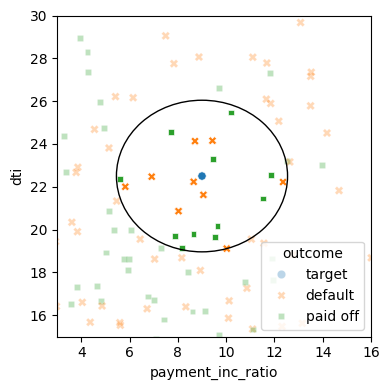

In [11]:
nbrs = knn.kneighbors(newloan)
maxDistance = np.max(nbrs[0][0])

fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome', 
                hue='outcome', data=loan200, alpha=0.3, ax=ax)
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome', 
                hue='outcome', 
                data=pd.concat([loan200.loc[0:0, :], loan200.loc[nbrs[1][0] + 1,:]]), 
                ax=ax, legend=False)
ellipse = Ellipse(xy=newloan.values[0], 
                  width=2 * maxDistance, height=2 * maxDistance,
                  edgecolor='black', fc='None', lw=1)
ax.add_patch(ellipse)
ax.set_xlim(3, 16)
ax.set_ylim(15, 30)

plt.tight_layout()
plt.show()

### R
R fits KNN with the same predictors and compares neighborhood decisions.


In [12]:
%%R
newloan <- loan200[1, 2:3, drop=FALSE]
knn_pred <- knn(train=loan200[-1, 2:3], test=newloan, cl=loan200[-1, 1], k=20)
knn_pred == 'paid off'

[1] TRUE


In [13]:
%%R
## look at the nearest 20 records and create circle
# we add 1 as we excluded the first data point for prediction
nearest_points <- loan200[attr(knn_pred, 'nn.index') + 1, ] 
nearest_points
dist <- attr(knn_pred, 'nn.dist')

circleFun <- function(center=c(0, 0), r=1, npoints=100){
  tt <- seq(0, 2 * pi, length.out=npoints - 1)
  xx <- center[1] + r * cos(tt)
  yy <- center[2] + r * sin(tt)
  return(data.frame(x=c(xx, xx[1]), y=c(yy, yy[1])))
}

circle_df <- circleFun(center=unlist(newloan), r=max(dist), npoints=201)

loan200_df <- loan200 # bind_cols(loan200, circle_df)
levels(loan200_df$outcome)

[1] "paid off" "default" 


In [14]:
%%R
# set first entry as target - requires adding additional level to factor
levels(loan200_df$outcome) <- c(levels(loan200_df$outcome), "newloan")
loan200_df[1, 'outcome'] <- 'newloan'
head(loan200_df)
levels(nearest_points$outcome) <- levels(loan200_df$outcome)

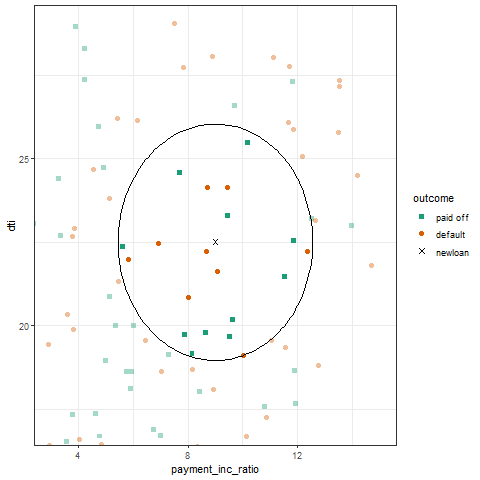

In [15]:
%%R
graph <- ggplot(data=loan200_df, aes(x=payment_inc_ratio, y=dti, color=outcome)) + # , shape=outcome)) +
  geom_point(aes(shape=outcome), size=2, alpha=0.4) +
  geom_point(data=nearest_points, aes(shape=outcome), size=2) +
  geom_point(data=loan200_df[1,], aes(shape=outcome), size=2) +
  scale_shape_manual(values=c(15, 16, 4)) +
  scale_color_manual(values = c("paid off"="#1b9e77", "default"="#d95f02", "newloan"='black')) +
  geom_path(data=circle_df, aes(x=x, y=y), color='black') +
  coord_cartesian(xlim=c(3, 15), ylim=c(17, 29)) +
  theme_bw() 
graph

### Summary: K-Nearest Neighbors

| Operation | Python | R | Notes |
|---|---|---|---|
| Model fit | `KNeighborsClassifier` | `knn`/nearest-neighbor helpers | Both classify by local neighborhood similarity. |
| Decision view | matplotlib boundary plots | ggplot decision region plots | Both visualize class regions from distances. |
| Prediction | `predict_proba()` / `predict()` | class vote outputs | Equivalent neighbor-voting classification logic. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.


## Standardization (Normalization, Z-Scores)


### Python
Python standardizes predictors before distance-based learning to avoid scale dominance.


In [16]:
loan_data = pd.read_csv(LOAN_DATA_CSV)
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)


predictors = ['payment_inc_ratio', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'

newloan = loan_data.loc[0:0, predictors]
print(newloan)
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

nbrs = knn.kneighbors(newloan)
print(X.iloc[nbrs[1][0], :])

   payment_inc_ratio  dti  revol_bal  revol_util
0             2.3932  1.0       1687         9.4
       payment_inc_ratio   dti  revol_bal  revol_util
35536            1.47212  1.46       1686        10.0
33651            3.38178  6.37       1688         8.4
25863            2.36303  1.39       1691         3.5
42953            1.28160  7.14       1684         3.9
43599            4.12244  8.98       1684         7.2


In [17]:
newloan = loan_data.loc[0:0, predictors]
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

scaler = preprocessing.StandardScaler()
scaler.fit(X * 1.0)

X_std = scaler.transform(X * 1.0)
newloan_std = scaler.transform(newloan * 1.0)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_std, y)

nbrs = knn.kneighbors(newloan_std)
print(X.iloc[nbrs[1][0], :])

       payment_inc_ratio   dti  revol_bal  revol_util
2080             2.61091  1.03       1218         9.7
1438             2.34343  0.51        278         9.9
30215            2.71200  1.34       1075         8.5
28542            2.39760  0.74       2917         7.4
44737            2.34309  1.37        488         7.2


### R
R standardizes variables before KNN to preserve distance comparability.


In [18]:
%%R
loan_df <- model.matrix(~ -1 + payment_inc_ratio + dti + revol_bal + 
                          revol_util, data=loan_data)
newloan <- loan_df[1, , drop=FALSE]
loan_df <- loan_df[-1,]
outcome <- loan_data[-1, 1]
knn_pred <- knn(train=loan_df, test=newloan, cl=outcome, k=5)
loan_df[attr(knn_pred, "nn.index"),]


      payment_inc_ratio  dti revol_bal revol_util
35537           1.47212 1.46      1686       10.0
33652           3.38178 6.37      1688        8.4
25864           2.36303 1.39      1691        3.5
42954           1.28160 7.14      1684        3.9
43600           4.12244 8.98      1684        7.2


In [19]:
%%R
loan_df <- model.matrix(~ -1 + payment_inc_ratio + dti + revol_bal + 
                          revol_util, data=loan_data)
loan_std <- scale(loan_df)
newloan_std <- loan_std[1, , drop=FALSE]
loan_std <- loan_std[-1,]
loan_df <- loan_df[-1,]
outcome <- loan_data[-1, 1]
knn_pred <- knn(train=loan_std, test=newloan_std, cl=outcome, k=5)
loan_df[attr(knn_pred, "nn.index"),]


      payment_inc_ratio  dti revol_bal revol_util
2081            2.61091 1.03      1218        9.7
1439            2.34343 0.51       278        9.9
30216           2.71200 1.34      1075        8.5
28543           2.39760 0.74      2917        7.4
44738           2.34309 1.37       488        7.2


### Summary: Standardization (Normalization, Z-Scores)

| Operation | Python | R | Notes |
|---|---|---|---|
| Scaling | `preprocessing.StandardScaler()` / transformers | `scale()`/matrix normalization | Both remove unit-scale bias in distance metrics. |
| Model input | scaled NumPy/pandas arrays | scaled model matrices | Equivalent standardized feature space. |
| KNN impact | improved distance comparability | improved distance comparability | Same rationale for preprocessing. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.


## KNN as a Feature Engine


### Python
Python uses nearest-neighbor outputs as engineered features for downstream modeling.


count    45342.000000
mean         0.501091
std          0.128728
min          0.000000
25%          0.400000
50%          0.500000
75%          0.600000
max          0.950000
Name: borrower_score, dtype: float64


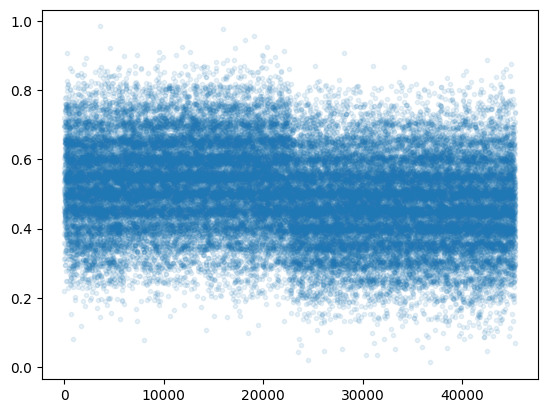

In [20]:
loan_data = pd.read_csv(LOAN_DATA_CSV)
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)

predictors = ['dti', 'revol_bal', 'revol_util', 'open_acc', 
              'delinq_2yrs_zero', 'pub_rec_zero']
outcome = 'outcome'

X = loan_data[predictors]
y = loan_data[outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)
plt.scatter(range(len(X)), [bs + random.gauss(0, 0.015) for bs in knn.predict_proba(X)[:,0]], 
            alpha=0.1, marker='.')
knn.predict_proba(X)[:, 0]

loan_data['borrower_score'] = knn.predict_proba(X)[:, 0]
print(loan_data['borrower_score'].describe())

### R
R derives neighbor-based features for subsequent predictive modeling.


In [21]:
%%R
borrow_df <- model.matrix(~ -1 + dti + revol_bal + revol_util + open_acc +
                            delinq_2yrs_zero + pub_rec_zero, data=loan_data)
borrow_knn <- knn(borrow_df, test=borrow_df, cl=loan_data[, 'outcome'], prob=TRUE, k=20)
prob <- attr(borrow_knn, "prob")
borrow_feature <- ifelse(borrow_knn == 'default', prob, 1 - prob)
summary(borrow_feature)

loan_data$borrower_score <- borrow_feature

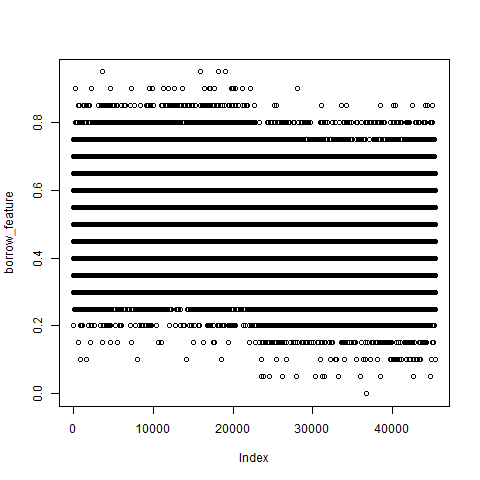

In [22]:
%%R
plot(borrow_feature)

### Summary: KNN as a Feature Engine

| Operation | Python | R | Notes |
|---|---|---|---|
| Feature derivation | neighbor-based engineered columns | neighbor-based engineered columns | Both reuse KNN structure for new predictors. |
| Pipeline role | feature augmentation before model fit | feature augmentation before model fit | Equivalent downstream modeling use. |
| Interpretation | local similarity signals | local similarity signals | Both encode neighborhood context. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.


# Tree Models
## A Simple Example

### Python
The package _scikit-learn_ has the class `DecisionTreeClassifier` to build a decision tree model. The function `plotDecisionTree` from the _dmba_ package can be used to visualize the tree. 

Python trains decision trees and inspects split logic for classification tasks.

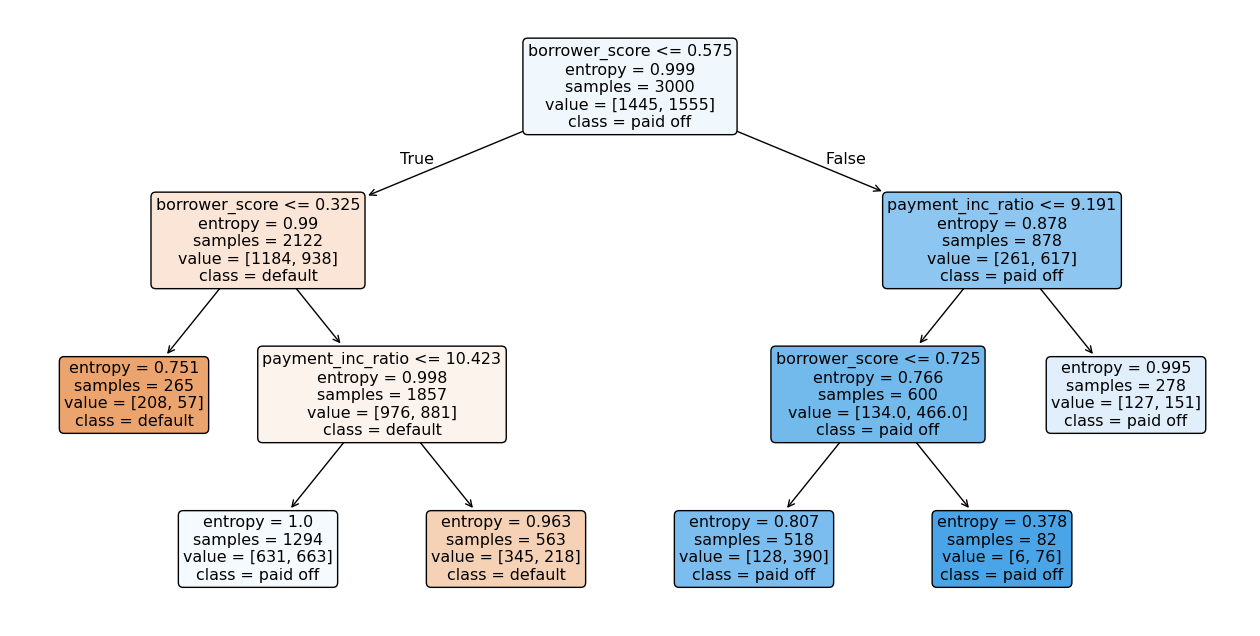

In [23]:
loan3000 = pd.read_csv(LOAN3000_CSV)

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(
    random_state=1,
    criterion='entropy',
    min_impurity_decrease=0.003
)

loan_tree.fit(X, y)

plt.figure(figsize=(16, 8))
plot_tree(
    loan_tree,
    feature_names=predictors,
    class_names=[str(c) for c in loan_tree.classes_],
    filled=True,
    rounded=True
)

plt.show()

In [24]:
print(textDecisionTree(loan_tree))

node=0 test node: go to node 1 if 0 <= 0.5750000178813934 else to node 6
  node=1 test node: go to node 2 if 0 <= 0.32500000298023224 else to node 3
    node=2 leaf node: [[np.float64(0.785), np.float64(0.215)]]
    node=3 test node: go to node 4 if 1 <= 10.42264986038208 else to node 5
      node=4 leaf node: [[np.float64(0.488), np.float64(0.512)]]
      node=5 leaf node: [[np.float64(0.613), np.float64(0.387)]]
  node=6 test node: go to node 7 if 1 <= 9.19082498550415 else to node 10
    node=7 test node: go to node 8 if 0 <= 0.7249999940395355 else to node 9
      node=8 leaf node: [[np.float64(0.247), np.float64(0.753)]]
      node=9 leaf node: [[np.float64(0.073), np.float64(0.927)]]
    node=10 leaf node: [[np.float64(0.457), np.float64(0.543)]]


### R
R trains classification trees and inspects split structure.


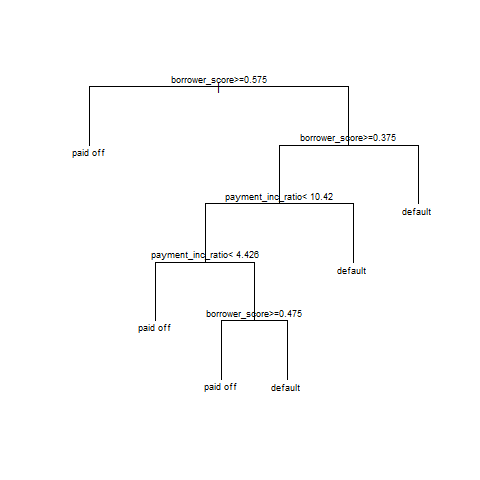

In [25]:
%%R
loan_tree <- rpart(outcome ~ borrower_score + payment_inc_ratio,
                   data=loan3000, control=rpart.control(cp=0.005))

plot(loan_tree, uniform=TRUE, margin=0.05)
text(loan_tree, cex=0.75)

In [26]:
%%R
loan_tree

n= 3000 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

 1) root 3000 1445 paid off (0.5183333 0.4816667)  
   2) borrower_score>=0.575 878  261 paid off (0.7027335 0.2972665) *
   3) borrower_score< 0.575 2122  938 default (0.4420358 0.5579642)  
     6) borrower_score>=0.375 1639  802 default (0.4893228 0.5106772)  
      12) payment_inc_ratio< 10.42265 1157  547 paid off (0.5272256 0.4727744)  
        24) payment_inc_ratio< 4.42601 334  139 paid off (0.5838323 0.4161677) *
        25) payment_inc_ratio>=4.42601 823  408 paid off (0.5042527 0.4957473)  
          50) borrower_score>=0.475 418  190 paid off (0.5454545 0.4545455) *
          51) borrower_score< 0.475 405  187 default (0.4617284 0.5382716) *
      13) payment_inc_ratio>=10.42265 482  192 default (0.3983402 0.6016598) *
     7) borrower_score< 0.375 483  136 default (0.2815735 0.7184265) *


### Summary: Tree Models

| Operation | Python | R | Notes |
|---|---|---|---|
| Tree fit | `DecisionTreeClassifier` | `rpart` | Both fit recursive partition models. |
| Rule extraction | `textDecisionTree` | tree print/plot outputs | Both expose human-readable split rules. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.

## The Recursive Partitioning Algorithm


### Python
Python visualizes recursive partitions in feature space to explain tree splits.


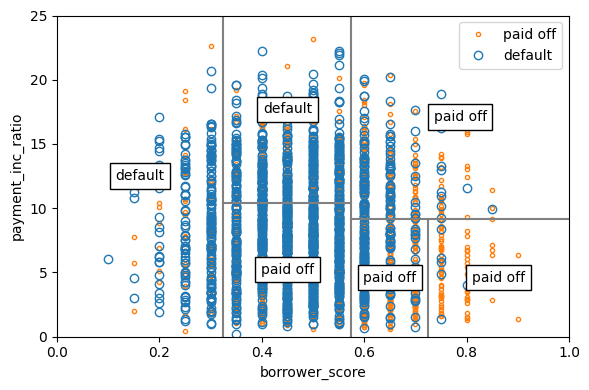

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))

loan3000.loc[loan3000.outcome=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.', 
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
loan3000.loc[loan3000.outcome=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o', 
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

x0 = 0.575
x1a = 0.325; y1b = 9.191
y2a = 10.423; x2b = 0.725
ax.plot((x0, x0), (0, 25), color='grey')
ax.plot((x1a, x1a), (0, 25), color='grey')
ax.plot((x0, 1), (y1b, y1b), color='grey')
ax.plot((x1a, x0), (y2a, y2a), color='grey')
ax.plot((x2b, x2b), (0, y1b), color='grey')

labels = [('default', (x1a / 2, 25 / 2)),
          ('default', ((x0 + x1a) / 2, (25 + y2a) / 2)),
          ('paid off', ((x0 + x1a) / 2, y2a / 2)),
          ('paid off', ((1 + x0) / 2, (y1b + 25) / 2)),
          ('paid off', ((1 + x2b) / 2, (y1b + 0) / 2)),
          ('paid off', ((x0 + x2b) / 2, (y1b + 0) / 2)),
         ]
for label, (x, y) in labels:
    ax.text(x, y, label, bbox={'facecolor':'white'},
            verticalalignment='center', horizontalalignment='center')

plt.tight_layout()
plt.show()

### R
R visualizes recursive partitions to show decision regions.


In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 


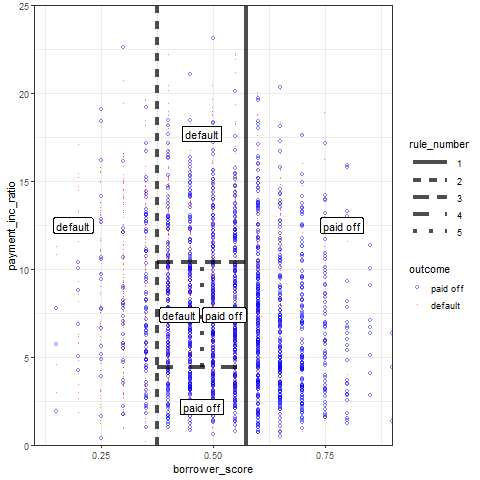

In [28]:
%%R
## Figure 6-4: View of partition rules
r_tree <- tibble(x1 = c(0.575, 0.375, 0.375, 0.375, 0.475),
                 x2 = c(0.575, 0.375, 0.575, 0.575, 0.475),
                 y1 = c(0,         0, 10.42, 4.426, 4.426),
                 y2 = c(25,       25, 10.42, 4.426, 10.42),
                 rule_number = factor(c(1, 2, 3, 4, 5)))
r_tree <- as.data.frame(r_tree)

rules <- tibble(x=c(0.575, 0.375, 0.4, 0.4, 0.475),
                y=c(24, 24, 10.42, 4.426, 9.42),
                rule_number = factor(c(1, 2, 3, 4, 5))) # , 3, 4, 5)))

labs <- tibble(x=c(.575 + (1-.575)/2, 
                   .375/2, 
                   (.375 + .575)/2,
                   (.375 + .575)/2, 
                   (.475 + .575)/2, 
                   (.375 + .475)/2
                   ),
               y=c(12.5, 
                   12.5,
                   10.42 + (25-10.42)/2,
                   4.426/2, 
                   4.426 + (10.42-4.426)/2,
                   4.426 + (10.42-4.426)/2
                   ),
               decision = factor(c('paid off', 'default', 'default', 'paid off', 'paid off', 'default')))

graph <- ggplot(data=loan3000, aes(x=borrower_score, y=payment_inc_ratio)) +
  geom_point( aes(color=outcome, shape=outcome), alpha=.5) +
  scale_color_manual(values=c('blue', 'red')) +
  scale_shape_manual(values = c(1, 46)) +
  geom_segment(data=r_tree, aes(x=x1, y=y1, xend=x2, yend=y2, linetype=rule_number), size=1.5, alpha=.7) +
  guides(color = guide_legend(override.aes = list(size=1.5)),
         linetype = guide_legend(keywidth=3, override.aes = list(size=1))) +
  scale_x_continuous(expand=c(0,0)) + 
  scale_y_continuous(expand=c(0,0)) + 
  coord_cartesian(ylim=c(0, 25)) +
  geom_label(data=labs, aes(x=x, y=y, label=decision)) +
  #theme(legend.position='bottom') +
  theme_bw()
graph

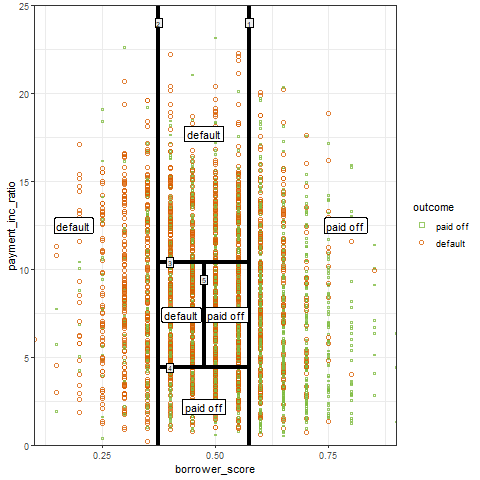

In [29]:
%%R
graph <- ggplot(data=loan3000, aes(x=borrower_score, y=payment_inc_ratio)) +
  geom_point( aes(color=outcome, shape=outcome, size=outcome), alpha=.8) +
  scale_color_manual(values = c("paid off"="#7fbc41", "default"="#d95f02")) +
  scale_shape_manual(values = c('paid off'=0, 'default'=1)) +
  scale_size_manual(values = c('paid off'=0.5, 'default'=2)) +
  geom_segment(data=r_tree, aes(x=x1, y=y1, xend=x2, yend=y2), size=1.5) + #, linetype=rule_number), size=1.5, alpha=.7) +
  guides(color = guide_legend(override.aes = list(size=1.5)),
         linetype = guide_legend(keywidth=3, override.aes = list(size=1))) +
  scale_x_continuous(expand=c(0,0)) + 
  scale_y_continuous(expand=c(0,0)) + 
  coord_cartesian(ylim=c(0, 25)) +
  geom_label(data=labs, aes(x=x, y=y, label=decision)) +
  geom_label(data=rules, aes(x=x, y=y, label=rule_number), 
             size=2.5,
             fill='#eeeeee', label.r=unit(0, "lines"), label.padding=unit(0.2, "lines")) +
  guides(color = guide_legend(override.aes = list(size=2))) +
  theme_bw()
graph

### Summary: The Recursive Partitioning Algorithm

| Operation | Python | R | Notes |
|---|---|---|---|
| Partition geometry | scatter + split overlays | ggplot partition boundaries | Both illustrate recursive splits in feature space. |
| Rule understanding | explicit threshold logic | explicit threshold logic | Equivalent interpretability objective. |
| Visualization | matplotlib layers | ggplot layers | Different APIs, same conceptual plot. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.


## Measuring Homogeneity or Impurity


### Python
Python computes impurity metrics to compare split quality criteria.


In [30]:
def entropyFunction(x):
    if x == 0: return 0
    return -x * math.log(x, 2) - (1 - x) * math.log(1 - x, 2)

def giniFunction(x):
    return x * (1 - x)

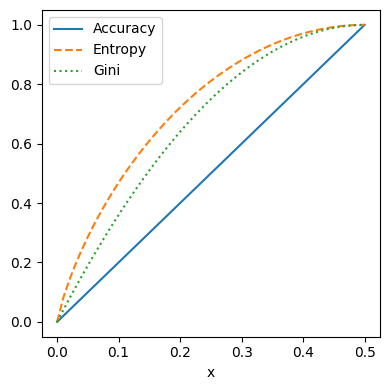

In [31]:
x = np.linspace(0, 0.5, 50)
impure = pd.DataFrame({
    'x': x,
    'Accuracy': 2 * x,
    'Gini': [giniFunction(xi) / giniFunction(.5) for xi in x],
    'Entropy': [entropyFunction(xi) for xi in x],
})

fig, ax = plt.subplots(figsize=(4, 4))

impure.plot(x='x', y='Accuracy', ax=ax, linestyle='solid')
impure.plot(x='x', y='Entropy', ax=ax, linestyle='--')
impure.plot(x='x', y='Gini', ax=ax, linestyle=':')

plt.tight_layout()
plt.show()

### R
R computes and visualizes impurity measures for split evaluation.


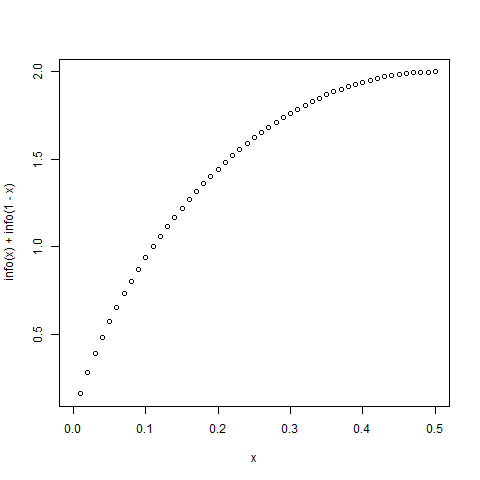

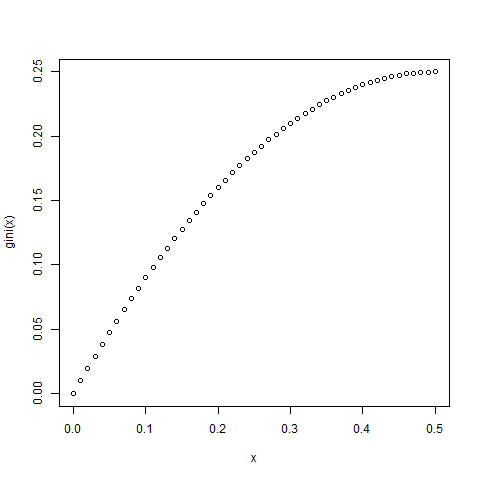

In [32]:
%%R
info <- function(x){
  info <- ifelse(x==0, 0, -x * log2(x) - (1-x) * log2(1-x))
  return(info)
}
x <- 0:50/100
plot(x, info(x) + info(1-x))

gini <- function(x){
  return(x * (1-x))
}
plot(x, gini(x))

In [33]:
%%R
impure <- data.frame(p = rep(x, 3),
                     impurity = c(2*x,
                                  gini(x)/gini(.5)*info(.5),
                                  info(x)),
                     type = rep(c('Accuracy', 'Gini', 'Entropy'), rep(51,3)))

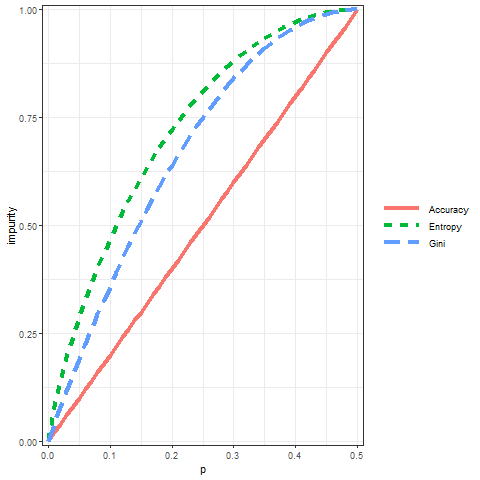

In [34]:
%%R
graph <- ggplot(data=impure, aes(x=p, y=impurity, linetype=type, color=type)) + 
  geom_line(size=1.5) +
  guides( linetype = guide_legend( keywidth=3, override.aes = list(size=1))) +
  scale_x_continuous(expand=c(0,0.01)) + 
  scale_y_continuous(expand=c(0,0.01)) + 
  theme_bw() +
  theme(legend.title=element_blank()) 
graph

### Summary: Measuring Homogeneity or Impurity

| Operation | Python | R | Notes |
|---|---|---|---|
| Impurity metrics | custom entropy/Gini functions | custom info/impurity functions | Both compare split quality mathematically. |
| Metric curves | NumPy + plot | data.frame + ggplot | Same metric behavior shown with different plotting stacks. |
| Split criterion | entropy/Gini comparisons | entropy/Gini comparisons | Equivalent optimization rationale. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.


# Bagging and the Random Forest
## Random Forest

### Python
Python builds bagged ensembles and random forests to improve generalization.


In [35]:
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

rf = RandomForestClassifier(n_estimators=500, random_state=1, 
                            oob_score=True)
rf.fit(X, y)
print(rf.oob_decision_function_)

[[0.18131868 0.81868132]
 [0.26704545 0.73295455]
 [0.93333333 0.06666667]
 ...
 [1.         0.        ]
 [0.73157895 0.26842105]
 [0.68085106 0.31914894]]


In [36]:
n_estimator = list(range(20, 510, 5))
oobScores = []
for n in n_estimator:
    rf = RandomForestClassifier(n_estimators=n, 
                                criterion='entropy', max_depth=5,
                                random_state=1, oob_score=True)
    rf.fit(X, y)
    oobScores.append(rf.oob_score_)

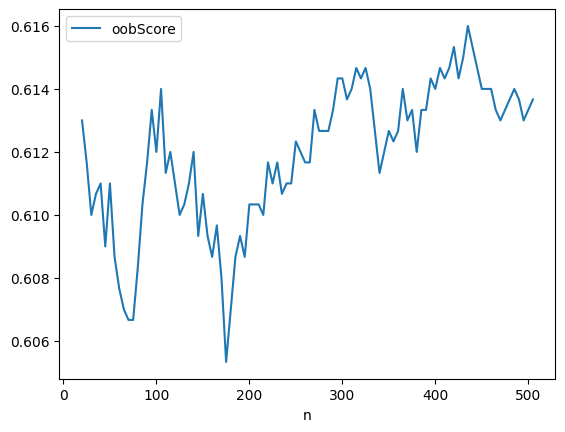

In [37]:
pd.DataFrame({
    'n': n_estimator, 
    'oobScore': oobScores
}).plot(x='n', y='oobScore')
plt.show()

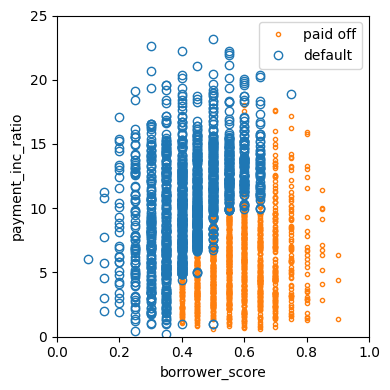

In [38]:
predictions = X.copy()
predictions['prediction'] = rf.predict(X)
predictions.head()

fig, ax = plt.subplots(figsize=(4, 4))

predictions.loc[predictions.prediction=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
predictions.loc[predictions.prediction=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

plt.tight_layout()
plt.show()

### R
R fits bagged/random-forest models and tracks OOB error behavior.


In [39]:
%%R
rf <- randomForest(outcome ~ borrower_score + payment_inc_ratio,
                   data=loan3000)
rf


Call:
 randomForest(formula = outcome ~ borrower_score + payment_inc_ratio,      data = loan3000) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 1

        OOB estimate of  error rate: 39.1%
Confusion matrix:
         paid off default class.error
paid off      965     590   0.3794212
default       583     862   0.4034602


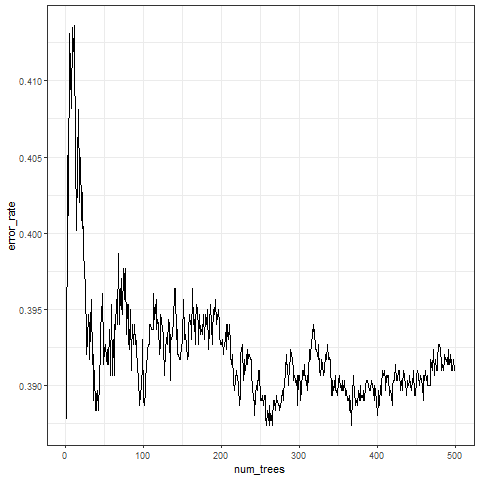

In [40]:
%%R
error_df = data.frame(error_rate=rf$err.rate[,'OOB'],
                      num_trees=1:rf$ntree)
graph <- ggplot(error_df, aes(x=num_trees, y=error_rate)) +
  geom_line()  +
  theme_bw()
graph

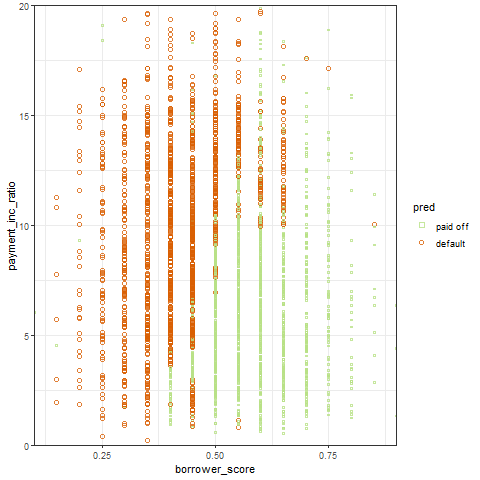

In [41]:
%%R
pred <- predict(rf, prob=TRUE)
rf_df <- cbind(loan3000, pred = pred)

graph <- ggplot(data=rf_df, aes(x=borrower_score, y=payment_inc_ratio, 
                       shape=pred, color=pred, size=pred)) +
  geom_point(alpha=.8) +
  scale_color_manual(values = c('paid off'='#b8e186', 'default'='#d95f02')) +
  scale_shape_manual(values = c('paid off'=0, 'default'=1)) +
  scale_size_manual(values = c('paid off'=0.5, 'default'=2)) +

  scale_x_continuous(expand=c(0,0)) + 
  scale_y_continuous(expand=c(0,0)) + 
  coord_cartesian(ylim=c(0, 20)) +
  guides(color = guide_legend(override.aes = list(size=2))) +
  theme_bw()
graph

A nice plot showing a gradient of predictions but not as illustrative as the prior plot (not in book)

In [42]:
%%R
# graph <- ggplot(data=rf_df, aes(x=borrower_score, y=payment_inc_ratio, color=prob_default)) +
#   geom_point(alpha=.6) +
#   scale_color_gradient2(low='blue', mid='white', high='red', midpoint=.5) +
#   scale_x_continuous(expand=c(0,0)) + 
#   scale_y_continuous(expand=c(0,0), lim=c(0, 20)) + 
#   theme(legend.position='bottom') +
#   geom_line(data=lda_df0, col='green', size=2, alpha=.8)
# graph

NULL


In [43]:
%%R
# graph
# dev.off()

NULL


### Summary: Bagging and the Random Forest

| Operation | Python | R | Notes |
|---|---|---|---|
| Ensemble fit | `RandomForestClassifier` | `randomForest` | Both average many trees to reduce variance. |
| Error tracking | custom error aggregation | OOB error plots | Both monitor model stability vs number of trees. |
| Predictions | `predict_proba()` | `predict(...)` | Python returns probabilities; R in this section uses class labels for visualization. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.


## Variable importance


### Python
This is different to R. The accuracy decrease is not available out of the box.

In [44]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 
              'payment_inc_ratio', 'revol_bal', 'revol_util', 
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 
              'open_acc', 'grade', 'emp_length', 'purpose_', 
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = loan_data[outcome]

rf_all = RandomForestClassifier(n_estimators=500, random_state=1)
rf_all.fit(X, y)

rf_all_entropy = RandomForestClassifier(n_estimators=500, random_state=1,
                                        criterion='entropy')
print(rf_all_entropy.fit(X, y))

RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=1)


In [45]:
rf = RandomForestClassifier(n_estimators=500)
scores = defaultdict(list)
 
# crossvalidate the scores on a number of different random splits of the data
for _ in range(3):
    train_X, valid_X, train_y, valid_y = train_test_split(X, y, 
                                                          test_size=0.3)
    rf.fit(train_X, train_y)
    acc = metrics.accuracy_score(valid_y, rf.predict(valid_X))
    for column in X.columns:
        X_t = valid_X.copy()
        X_t[column] = np.random.permutation(X_t[column].values)
        shuff_acc = metrics.accuracy_score(valid_y, rf.predict(X_t))
        scores[column].append((acc-shuff_acc)/acc)
print('Features sorted by their score:')
print(sorted([(round(np.mean(score), 4), feat) for
              feat, score in scores.items()], reverse=True))

Features sorted by their score:
[(np.float64(0.072), 'borrower_score'), (np.float64(0.0379), 'grade'), (np.float64(0.0268), 'term_60 months'), (np.float64(0.0161), 'annual_inc'), (np.float64(0.0099), 'payment_inc_ratio'), (np.float64(0.005), 'dti'), (np.float64(0.0034), 'purpose__small_business'), (np.float64(0.0017), 'home__RENT'), (np.float64(0.0015), 'purpose_small_business'), (np.float64(0.001), 'open_acc'), (np.float64(0.001), 'emp_length'), (np.float64(0.0007), 'delinq_2yrs_zero'), (np.float64(0.0006), 'revol_bal'), (np.float64(0.0006), 'purpose_other'), (np.float64(0.0006), 'purpose_major_purchase'), (np.float64(0.0006), 'purpose__home_improvement'), (np.float64(0.0003), 'purpose_credit_card'), (np.float64(0.0003), 'purpose__major_purchase'), (np.float64(0.0002), 'purpose_home_improvement'), (np.float64(0.0002), 'emp_len__ > 1 Year'), (np.float64(0.0001), 'purpose_wedding'), (np.float64(0.0001), 'purpose_medical'), (np.float64(-0.0), 'revol_util'), (np.float64(0.0), 'purpose_mov

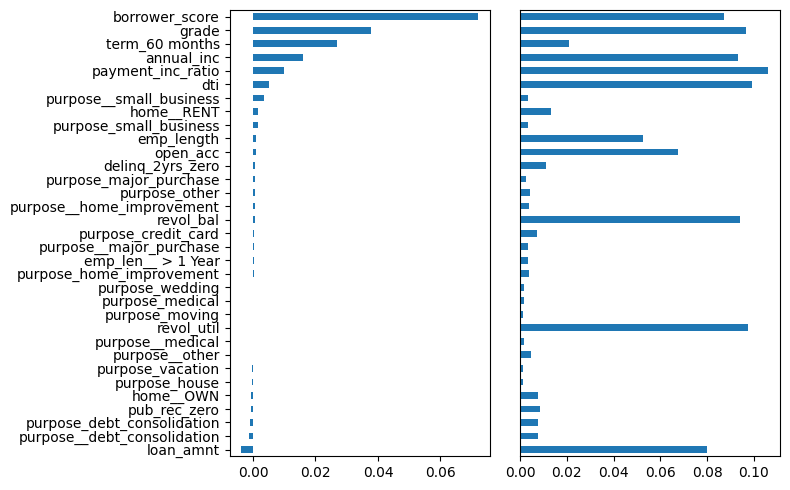

In [46]:
importances = rf_all.feature_importances_

df = pd.DataFrame({
    'feature': X.columns, 
    'Accuracy decrease': [np.mean(scores[column]) for column in 
                         X.columns],
    'Gini decrease': rf_all.feature_importances_, 
    'Entropy decrease': rf_all_entropy.feature_importances_,
})
df = df.sort_values('Accuracy decrease')

fig, axes = plt.subplots(ncols=2, figsize=(8, 5))
ax = df.plot(kind='barh', x='feature', y='Accuracy decrease', 
             legend=False, ax=axes[0])
ax.set_ylabel('')

ax = df.plot(kind='barh', x='feature', y='Gini decrease', 
             legend=False, ax=axes[1])
ax.set_ylabel('')
ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

### R
R ranks predictors by random-forest importance metrics.


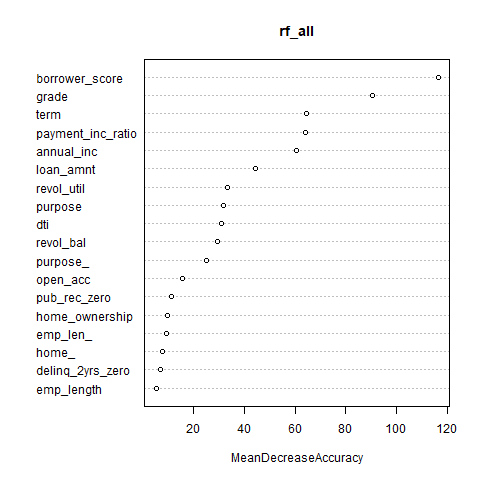

In [47]:
%%R
rf_all <- randomForest(outcome ~ ., data=loan_data, importance=TRUE)
rf_all

varImpPlot(rf_all, type=1)

imp1 <- importance(rf_all, type=1)
imp2 <- importance(rf_all, type=2)
idx <- order(imp1[,1])
nms <- factor(row.names(imp1)[idx], levels=row.names(imp1)[idx])
imp <- data.frame(Predictor = rep(nms, 2),
                  Importance = c(imp1[idx, 1], imp2[idx, 1]),
                  Type = rep( c('Accuracy Decrease', 'Gini Decrease'), rep(nrow(imp1), 2)))

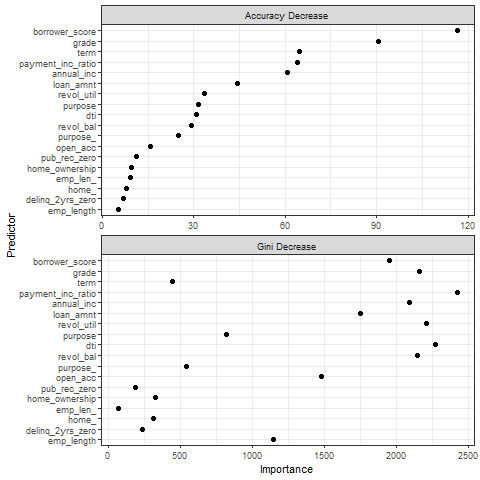

In [48]:
%%R
graph <- ggplot(imp) + 
  geom_point(aes(y=Predictor, x=Importance), size=2, stat="identity") + 
  facet_wrap(~Type, ncol=1, scales="free_x") + 
  theme(
    panel.grid.major.x = element_blank() ,
    panel.grid.major.y = element_line(linetype=3, color="darkgray") ) +
  theme_bw()
graph

#### search over hyperparameter space (not in book); this takes a while

In [49]:
%%R
# loan_data1 <- loan_data0[,-which(names(loan_data0) %in% 'emp_length')]
# loan_data1$term = factor(loan_data1$term)
# loan_data1$emp_length = factor(loan_data1$emp_length>1)

# params <- data.frame(nodesize = c(5, 15, 25, 5, 10, 25),
#                      mtry = c(3, 3, 3, 5, 5, 5))
# rf_list <- vector('list', 6)
# for(i in 1:nrow(params)){
#   rf_list[[i]] <- randomForest(outcome ~ ., data=loan_data, mtry=params[i, 'mtry'],
#                                nodesize = params[i,'nodesize'], ntree=100)
# }

# rf_list[[1]]$confusion

NULL


### Summary: Variable importance

| Operation | Python | R | Notes |
|---|---|---|---|
| Importance extraction | `feature_importances_` | `importance(...)` | Both rank predictors by contribution. |
| Visualization | bar/point plots | ggplot ranking chart | Same comparative interpretation of variable impact. |
| Model insight | global feature influence | global feature influence | Equivalent diagnostic objective. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.

# Boosting
## XGBoost

### Python
Python trains gradient boosting/XGBoost classifiers for higher predictive accuracy.


In [50]:
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = pd.Series([1 if o == 'default' else 0 for o in loan3000[outcome]])

xgb = XGBClassifier(objective='binary:logistic', subsample=.63, 
                    eval_metric='error')
print(xgb.fit(X, y))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


In [51]:
xgb_df = X.copy()
xgb_df['prediction'] = ['default' if p == 1 else 'paid off' for p in xgb.predict(X)]
xgb_df['prob_default'] = xgb.predict_proba(X)[:, 0]
print(xgb_df.head())

   borrower_score  payment_inc_ratio prediction  prob_default
0            0.40            5.11135   paid off      0.837470
1            0.40            5.43165    default      0.258429
2            0.70            9.23003    default      0.218399
3            0.40            2.33482   paid off      0.869448
4            0.45           12.10320    default      0.071927


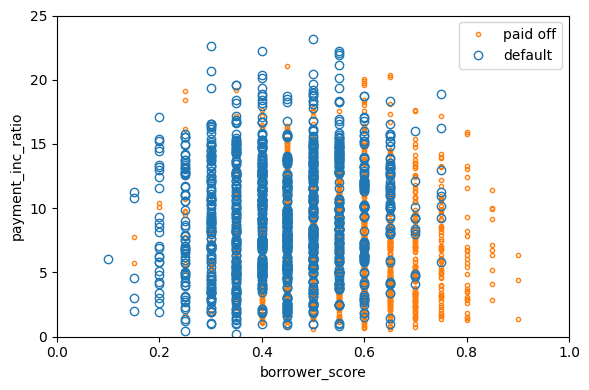

In [52]:
fig, ax = plt.subplots(figsize=(6, 4))

xgb_df.loc[xgb_df.prediction=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.', 
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
xgb_df.loc[xgb_df.prediction=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o', 
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

plt.tight_layout()
plt.show()

In [53]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 
              'payment_inc_ratio', 'revol_bal', 'revol_util', 
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 
              'open_acc', 'grade', 'emp_length', 'purpose_', 
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = pd.Series([1 if o == 'default' else 0 for o in loan_data[outcome]])

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=10000)

xgb_default = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=0, learning_rate=0.3, subsample=1,
                            eval_metric='error')
xgb_default.fit(train_X, train_y)

xgb_penalty = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=1000, learning_rate=0.1, subsample=0.63,
                            eval_metric='error')
print(xgb_penalty.fit(train_X, train_y))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, ...)


### R
R trains XGBoost models and visualizes probability landscapes.


In [54]:
%%R
predictors <- data.matrix(loan3000[, c('borrower_score', 'payment_inc_ratio')])
label <- factor(loan3000[,'outcome'])

xgb <- xgboost(x = predictors, y = label,
               objective = 'binary:logistic',
               subsample = 0.63, eta = 0.1,
               nrounds = 100, eval_metric = 'error')

pred <- predict(xgb, newdata = predictors)
xgb_df <- cbind(loan3000, pred_default = pred > 0.5, prob_default = pred)

In addition: Warning message:
In throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '",  :
  Parameter 'eta' has been renamed to 'learning_rate'. This warning will become an error in a future version.


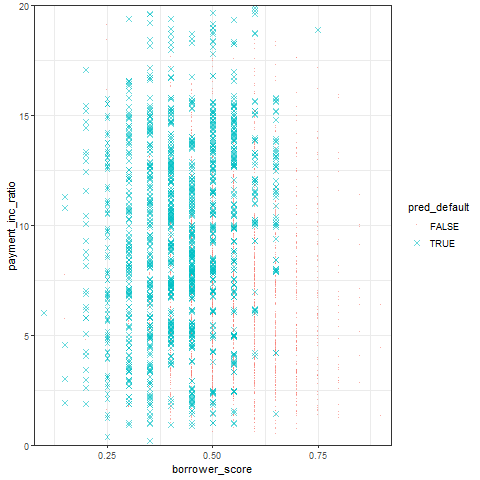

In [55]:
%%R
graph <- ggplot(data=xgb_df, aes(x=borrower_score, y=payment_inc_ratio, 
                        color=pred_default, shape=pred_default)) +
  geom_point(alpha=0.6, size=2) +
  scale_shape_manual( values=c(46, 4)) +
  scale_x_continuous(expand=c(0.03, 0)) + 
  scale_y_continuous(expand=c(0, 0)) + 
  coord_cartesian(ylim=c(0, 20)) +
  theme_bw()
graph

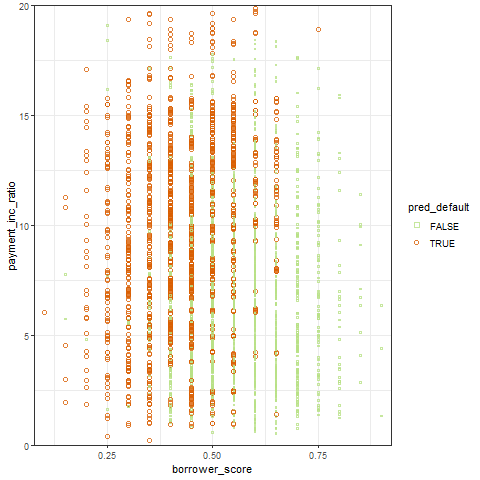

In [56]:
%%R
graph <- ggplot(data=xgb_df, aes(x=borrower_score, y=payment_inc_ratio, 
                color=pred_default, shape=pred_default, size=pred_default)) +
  geom_point(alpha=.8) +
  scale_color_manual(values = c('FALSE'='#b8e186', 'TRUE'='#d95f02')) +
  scale_shape_manual(values = c('FALSE'=0, 'TRUE'=1)) +
  scale_size_manual(values = c('FALSE'=0.5, 'TRUE'=2)) +

  scale_x_continuous(expand=c(0.03, 0)) + 
  scale_y_continuous(expand=c(0, 0)) + 
  coord_cartesian(ylim=c(0, 20)) +
  guides(color = guide_legend(override.aes = list(size=2))) +
  theme_bw()
graph

### Summary: Boosting

| Operation | Python | R | Notes |
|---|---|---|---|
| Model fit | `XGBClassifier` | `xgboost` | Both train gradient-boosted trees. |
| Predictions | `predict()` / `predict_proba()` | `predict()` | Python returns class labels and probabilities; in R the code uses predicted probabilities and thresholds them at 0.5. |
| Decision plot | scatter plot of predicted classes | ggplot classification map | Both plot predicted classes over the two input features; no explicit probability surface is computed in the shown code. |
| Iteration control | `n_estimators`, `learning_rate` | `nrounds`, `eta` | Equivalent boosting controls across APIs. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.

## Regularization: Avoiding Overfitting


### Python
Python applies early stopping and regularization controls to reduce overfit risk.


In [57]:
pred_default = xgb_default.predict_proba(train_X)[:, 1]
error_default = abs(train_y - pred_default) > 0.5
print('default (train): ', np.mean(error_default))

pred_default = xgb_default.predict_proba(valid_X)[:, 1]
error_default = abs(valid_y - pred_default) > 0.5
print('default: ', np.mean(error_default))

pred_penalty = xgb_penalty.predict_proba(valid_X)[:, 1]
error_penalty = abs(valid_y - pred_penalty) > 0.5
print('penalty: ', np.mean(error_penalty))

default (train):  0.10670024333654009
default:  0.354
penalty:  0.3235


In [58]:
results = []
for ntree_limit in range(1, 250):
    iteration_range = [1, ntree_limit + 1]
    train_default = xgb_default.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    train_penalty = xgb_penalty.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    pred_default = xgb_default.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    pred_penalty = xgb_penalty.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    results.append({
        'iterations': ntree_limit,
        'default train': np.mean(abs(train_y - train_default) > 0.5),
        'penalty train': np.mean(abs(train_y - train_penalty) > 0.5),
        'default test': np.mean(abs(valid_y - pred_default) > 0.5),
        'penalty test': np.mean(abs(valid_y - pred_penalty) > 0.5),
    })

results = pd.DataFrame(results)
print(results.head())

   iterations  default train  penalty train  default test  penalty test
0           1       0.339851       0.359997        0.3479        0.3572
1           2       0.332126       0.345198        0.3447        0.3426
2           3       0.326269       0.343048        0.3342        0.3438
3           4       0.322166       0.340388        0.3340        0.3394
4           5       0.320072       0.338096        0.3351        0.3428


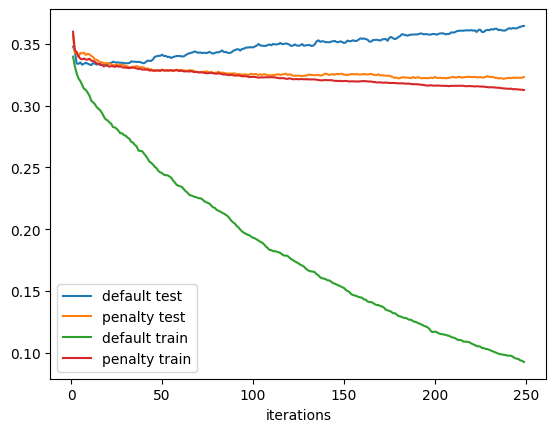

In [59]:
ax = results.plot(x='iterations', y='default test')
results.plot(x='iterations', y='penalty test', ax=ax)
results.plot(x='iterations', y='default train', ax=ax)
results.plot(x='iterations', y='penalty train', ax=ax)
plt.show()

### R
R applies regularization controls and compares train/test error trajectories.


In [60]:
%%R
library(xgboost)

set.seed(400820)

predictors <- data.matrix(loan_data[, setdiff(names(loan_data), "outcome")])
label <- ifelse(loan_data$outcome == "default", 1, 0)

test_idx <- sample(nrow(loan_data), 10000)

dtrain <- xgb.DMatrix(data = predictors[-test_idx, ], label = label[-test_idx])

dtest <- xgb.DMatrix(data = predictors[test_idx, ], label = label[test_idx])

xgb_default <- xgb.train(
  data = dtrain,
  objective = "binary:logistic",
  nrounds = 250,
  verbose = 0,
  eval_metric = "error"
)

pred_default <- predict(xgb_default, dtest)
mean((pred_default > 0.5) != label[test_idx])

[1] 0.356


In addition: Warning messages:
1: In check.deprecation(deprecated_train_params, match.call(), ...) :
  Passed invalid function arguments: eval_metric. These should be passed as a list to argument 'params'. Conversion from argument to 'params' entry will be done automatically, but this behavior will become an error in a future version.
2: In check.custom.obj(params, objective) :
  Argument 'objective' is only for custom objectives. For built-in objectives, pass the objective under 'params'. This warning will become an error in a future version.


In [61]:
%%R
xgb_penalty <- xgb.train(
  params = list(
    objective = "binary:logistic",
    eta = 0.1,
    subsample = 0.63,
    lambda = 1000,
    eval_metric = "error"
  ),
  data = dtrain,
  nrounds = 250,
  verbose = 0
)

pred_penalty <- predict(xgb_penalty, dtest)
mean((pred_penalty > 0.5) != label[test_idx])

[1] 0.3322


In [62]:
%%R

n_iter <- 250L

x_test <- predictors[test_idx, , drop = FALSE]
y_test <- label[test_idx]

error_default <- numeric(n_iter)
error_penalty <- numeric(n_iter)

for (i in seq_len(n_iter)) {
  pred_default <- predict(xgb_default, x_test, iterationrange = c(1L, i))

  error_default[i] <- mean((pred_default > 0.5) != y_test)

  pred_penalty <- predict(xgb_penalty, x_test, iterationrange = c(1L, i))

  error_penalty[i] <- mean((pred_penalty > 0.5) != y_test)
}

errors <- data.frame(
  iter = seq_len(n_iter),
  default_test = error_default,
  penalty_test = error_penalty
)

errors_long <- rbind(
  data.frame(iter = errors$iter, error = errors$default_test, type = "default test"),
  data.frame(iter = errors$iter, error = errors$penalty_test, type = "penalty test")
)

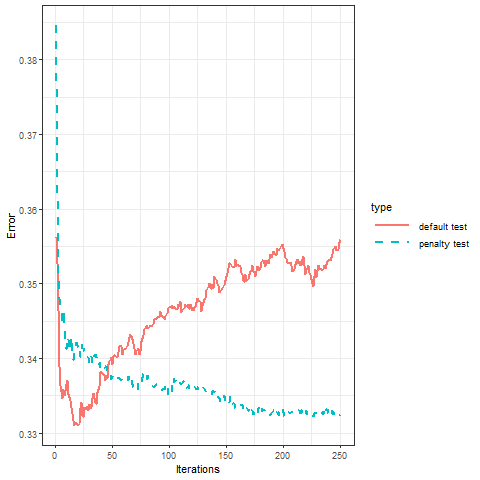

In [63]:
%%R

graph <- ggplot(errors_long, aes(x = iter, y = error, group = type)) +
  geom_line(aes(linetype = type, color = type), size = 1) +
  scale_linetype_manual(values = c("solid", "dashed")) +
  theme_bw() +
  theme(legend.key.width = unit(1.5, "cm")) +
  labs(x = "Iterations", y = "Error") +
  guides(color = guide_legend(override.aes = list(size = 1)))

graph

### Summary: Regularization: Avoiding Overfitting

| Operation | Python | R | Notes |
|---|---|---|---|
| Overfit monitoring | train/test error vs iterations | test error vs iterations | Python computes both train and test error curves; R computes only test error curves in the shown code. |
| Regularization knobs | `learning_rate`, `max_depth`, `subsample`, `lambda` | `eta`, `subsample`, `lambda` | These are the regularization controls explicitly used in the code; `max_depth` is set in the Python models but not in the R penalty model shown here. |
| Iteration analysis | staged predictions (`iteration_range`) | staged predictions (`iterationrange`) | Both evaluate performance across boosting steps. |
| Decision criterion | inspect error curves manually | inspect error curves manually | No automatic early stopping is used in the shown code. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.

## Hyperparameters and Cross-Validation


### Python
Python evaluates hyperparameter combinations with resampling-based validation.


In [64]:
idx = np.random.choice(range(5), size=len(X), replace=True)
error = []
for eta, max_depth in product([0.1, 0.5, 0.9], [3, 6, 9]):
    xgb = XGBClassifier(objective='binary:logistic', n_estimators=250, 
                        max_depth=max_depth, learning_rate=eta,
                        eval_metric='error')
    cv_error = []
    for k in range(5):
        fold_idx = idx == k
        train_X = X.loc[~fold_idx]; train_y = y[~fold_idx]
        valid_X = X.loc[fold_idx]; valid_y = y[fold_idx]

        xgb.fit(train_X, train_y)
        pred = xgb.predict_proba(valid_X)[:, 1]
        cv_error.append(np.mean(abs(valid_y - pred) > 0.5))
    error.append({
        'eta': eta,
        'max_depth': max_depth,
        'avg_error': np.mean(cv_error)
    })
    print(error[-1])
errors = pd.DataFrame(error)
print(errors)

{'eta': 0.1, 'max_depth': 3, 'avg_error': np.float64(0.3286483036755906)}
{'eta': 0.1, 'max_depth': 6, 'avg_error': np.float64(0.33669618919796235)}
{'eta': 0.1, 'max_depth': 9, 'avg_error': np.float64(0.34681731182982894)}
{'eta': 0.5, 'max_depth': 3, 'avg_error': np.float64(0.3397728058897796)}
{'eta': 0.5, 'max_depth': 6, 'avg_error': np.float64(0.36424626321218706)}
{'eta': 0.5, 'max_depth': 9, 'avg_error': np.float64(0.3720725886301959)}
{'eta': 0.9, 'max_depth': 3, 'avg_error': np.float64(0.3501921694368625)}
{'eta': 0.9, 'max_depth': 6, 'avg_error': np.float64(0.38360167600604067)}
{'eta': 0.9, 'max_depth': 9, 'avg_error': np.float64(0.38121575253221895)}
   eta  max_depth  avg_error
0  0.1          3   0.328648
1  0.1          6   0.336696
2  0.1          9   0.346817
3  0.5          3   0.339773
4  0.5          6   0.364246
5  0.5          9   0.372073
6  0.9          3   0.350192
7  0.9          6   0.383602
8  0.9          9   0.381216


In [65]:
print(errors.pivot_table(index='eta', columns='max_depth', values='avg_error') * 100)

max_depth          3          6          9
eta                                       
0.1        32.864830  33.669619  34.681731
0.5        33.977281  36.424626  37.207259
0.9        35.019217  38.360168  38.121575


### R
R evaluates hyperparameters via repeated sampling and error aggregation.


In [66]:
%%R
library(xgboost)

set.seed(400820)

N <- nrow(loan_data)
fold_number <- sample(1:5, N, replace = TRUE)

predictors <- data.matrix(loan_data[, setdiff(names(loan_data), "outcome")])
label <- ifelse(loan_data$outcome == "default", 1, 0)

params <- data.frame(eta = rep(c(.1, .5, .9), 3), max_depth = rep(c(3, 6, 12), each = 3))

error <- matrix(0, nrow = nrow(params), ncol = 5)

for (i in 1:nrow(params)) {
  for (k in 1:5) {

    fold_idx <- which(fold_number == k)

    dtrain <- xgb.DMatrix(data = predictors[-fold_idx, ], label = label[-fold_idx])

    dtest <- xgb.DMatrix(data = predictors[fold_idx, ], label = label[fold_idx])

    model <- xgb.train(
      params = list(
        objective = "binary:logistic",
        eta = params$eta[i],
        max_depth = params$max_depth[i],
        eval_metric = "error"
      ),
      data = dtrain,
      nrounds = 100,
      verbose = 0
    )

    pred <- predict(model, dtest)

    error[i, k] <- mean((pred > 0.5) != label[fold_idx])
  }
}

avg_error <- 100 * rowMeans(error)
cbind(params, avg_error)

  eta max_depth avg_error
1 0.1         3  32.87627
2 0.5         3  33.38361
3 0.9         3  33.96084
4 0.1         6  33.13310
5 0.5         6  35.66607
6 0.9         6  37.37816
7 0.1        12  34.96274
8 0.5        12  37.13764
9 0.9        12  37.79391


### Summary: Hyperparameters and Cross-Validation

| Operation | Python | R | Notes |
|---|---|---|---|
| Tuning strategy | random fold assignment with repeated validation | random fold assignment with repeated validation | Both use repeated random splits, not strict k-fold cross-validation. |
| Parameter grid | explicit loops (`eta`, `max_depth`) | parameter table + loops | Equivalent grid-search patterns. |
| Aggregation | mean validation error (DataFrame / pivot) | mean validation error (matrix → average) | Equivalent model-selection evidence. |
| Selection | minimum average validation error | minimum average validation error | Same objective for final model choice. |

Python generally exposes modeling steps through estimator objects, while R generally expresses the same steps through concise statistical functions and formula interfaces.